In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RAW_PATH = "../data/raw/"
PROCESSED_PATH = "../data/processed/"
MODEL_PATH = "../model/"
VISUAL_PATH = "../visualization/"

In [2]:
train = pd.read_csv(RAW_PATH + "train.csv")
features = pd.read_csv(RAW_PATH + "features.csv")
stores = pd.read_csv(RAW_PATH + "stores.csv")

print("Train shape:", train.shape)
print("Features shape:", features.shape)
print("Stores shape:", stores.shape)

train.head()

Train shape: (421570, 5)
Features shape: (8190, 12)
Stores shape: (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [3]:
print("Train columns:")
print(train.columns.tolist())

print("\nFeatures columns:")
print(features.columns.tolist())

print("\nStores columns:")
print(stores.columns.tolist())

Train columns:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

Features columns:
['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

Stores columns:
['Store', 'Type', 'Size']


In [4]:
print("Train missing values:")
display(train.isnull().sum())

print("\nFeatures missing values:")
display(features.isnull().sum())

print("\nStores missing values:")
display(stores.isnull().sum())

Train missing values:


Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64


Features missing values:


Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64


Stores missing values:


Store    0
Type     0
Size     0
dtype: int64

In [5]:
df = train.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

df = df.merge(
    stores,
    on="Store",
    how="left"
)

print("Merged dataset shape:", df.shape)
df.head()

Merged dataset shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [6]:
df["Date"] = pd.to_datetime(df["Date"])

df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["week"] = df["Date"].dt.isocalendar().week.astype(int)
df["day"] = df["Date"].dt.day
df["quarter"] = df["Date"].dt.quarter

df[["Date", "year", "month", "week", "day", "quarter"]].head()

,Date,year,month,week,day,quarter
0,2010-02-05,2010,2,5,5,1
1,2010-02-12,2010,2,6,12,1
2,2010-02-19,2010,2,7,19,1
3,2010-02-26,2010,2,8,26,1
4,2010-03-05,2010,3,9,5,1


In [7]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (421570, 21)
<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  str           
 15  

In [9]:
df_clean = df.copy()

# MarkDown missing values mean no markdown / no promotion
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

for col in markdown_cols:
    df_clean[col] = df_clean[col].fillna(0)

# CPI and Unemployment use median
df_clean["CPI"] = df_clean["CPI"].fillna(df_clean["CPI"].median())
df_clean["Unemployment"] = df_clean["Unemployment"].fillna(df_clean["Unemployment"].median())

print("Missing values after cleaning:")
df_clean.isnull().sum()

Missing values after cleaning:


Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
year            0
month           0
week            0
day             0
quarter         0
dtype: int64

In [10]:
duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [11]:
total_sales = df_clean["Weekly_Sales"].sum()
avg_weekly_sales = df_clean["Weekly_Sales"].mean()
total_store = df_clean["Store"].nunique()
total_department = df_clean["Dept"].nunique()
date_min = df_clean["Date"].min()
date_max = df_clean["Date"].max()

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Average Weekly Sales",
        "Total Stores",
        "Total Departments",
        "Start Date",
        "End Date"
    ],
    "Value": [
        total_sales,
        avg_weekly_sales,
        total_store,
        total_department,
        date_min,
        date_max
    ]
})

kpi_summary

,Metric,Value
0,Total Sales,6737218987.11
1,Average Weekly Sales,15981.258123
2,Total Stores,45
3,Total Departments,81
4,Start Date,2010-02-05 00:00:00
5,End Date,2012-10-26 00:00:00


In [12]:
monthly_sales = df_clean.groupby(
    pd.Grouper(key="Date", freq="ME")
).agg({
    "Weekly_Sales": "sum"
}).reset_index()

monthly_sales = monthly_sales.rename(columns={
    "Weekly_Sales": "total_sales"
})

monthly_sales.head()

,Date,total_sales
0,2010-02-28,1.903330e+08
1,2010-03-31,1.819198e+08
2,2010-04-30,2.314124e+08
3,2010-05-31,1.867109e+08
4,2010-06-30,1.922462e+08


In [13]:
sales_by_store = df_clean.groupby("Store", as_index=False).agg({
    "Weekly_Sales": "sum"
})

sales_by_store = sales_by_store.rename(columns={
    "Weekly_Sales": "total_sales"
})

sales_by_store = sales_by_store.sort_values("total_sales", ascending=False)

sales_by_store.head(10)

,Store,total_sales
19,20,3.013978e+08
3,4,2.995440e+08
13,14,2.889999e+08
12,13,2.865177e+08
1,2,2.753824e+08
9,10,2.716177e+08
26,27,2.538559e+08
5,6,2.237561e+08
0,1,2.224028e+08
38,39,2.074455e+08


In [14]:
sales_by_dept = df_clean.groupby("Dept", as_index=False).agg({
    "Weekly_Sales": "sum"
})

sales_by_dept = sales_by_dept.rename(columns={
    "Weekly_Sales": "total_sales"
})

sales_by_dept = sales_by_dept.sort_values("total_sales", ascending=False)

sales_by_dept.head(10)

,Dept,total_sales
73,92,4.839433e+08
76,95,4.493202e+08
36,38,3.931181e+08
60,72,3.057252e+08
71,90,2.910685e+08
38,40,2.889360e+08
1,2,2.806112e+08
72,91,2.167817e+08
12,13,1.973216e+08
7,8,1.942808e+08


In [15]:
sales_by_holiday = df_clean.groupby("IsHoliday", as_index=False).agg({
    "Weekly_Sales": ["sum", "mean"]
})

sales_by_holiday.columns = [
    "is_holiday",
    "total_sales",
    "avg_weekly_sales"
]

sales_by_holiday

,is_holiday,total_sales,avg_weekly_sales
0,False,6.231919e+09,15901.445069
1,True,5.052996e+08,17035.823187


In [16]:
sales_by_store_type = df_clean.groupby("Type", as_index=False).agg({
    "Weekly_Sales": ["sum", "mean"],
    "Store": "nunique"
})

sales_by_store_type.columns = [
    "store_type",
    "total_sales",
    "avg_weekly_sales",
    "total_stores"
]

sales_by_store_type = sales_by_store_type.sort_values(
    "total_sales",
    ascending=False
)

sales_by_store_type

,store_type,total_sales,avg_weekly_sales,total_stores
0,A,4.331015e+09,20099.568043,22
1,B,2.000701e+09,12237.075977,17
2,C,4.055035e+08,9519.532538,6


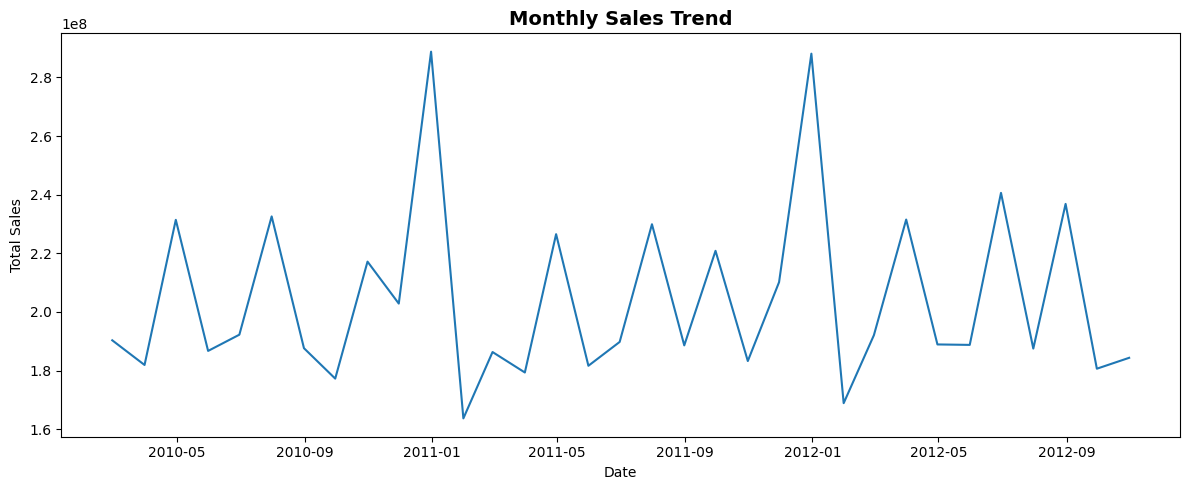

In [17]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="Date",
    y="total_sales"
)

plt.title("Monthly Sales Trend", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "monthly_sales_trend.png", dpi=300)
plt.show()

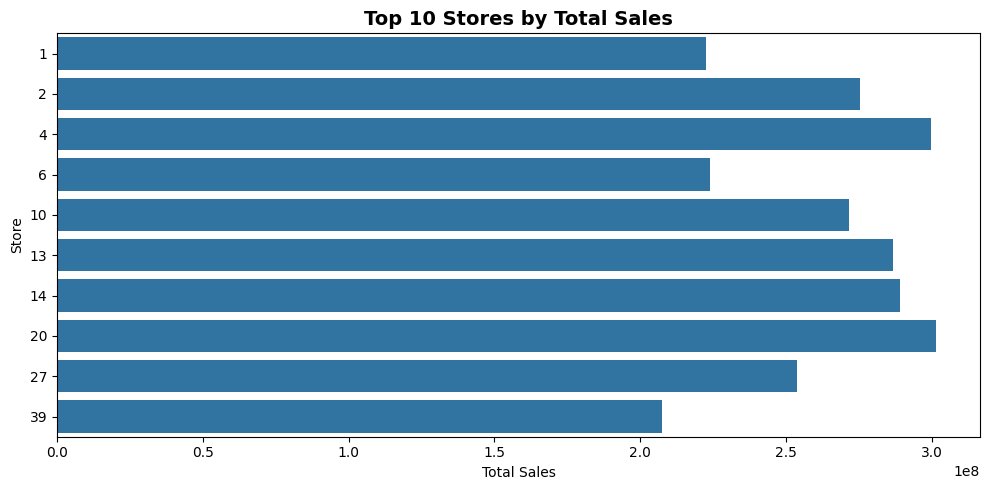

In [18]:
top_10_store = sales_by_store.head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_10_store,
    x="total_sales",
    y="Store",
    orient="h"
)

plt.title("Top 10 Stores by Total Sales", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Store")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "top_10_stores_by_sales.png", dpi=300)
plt.show()

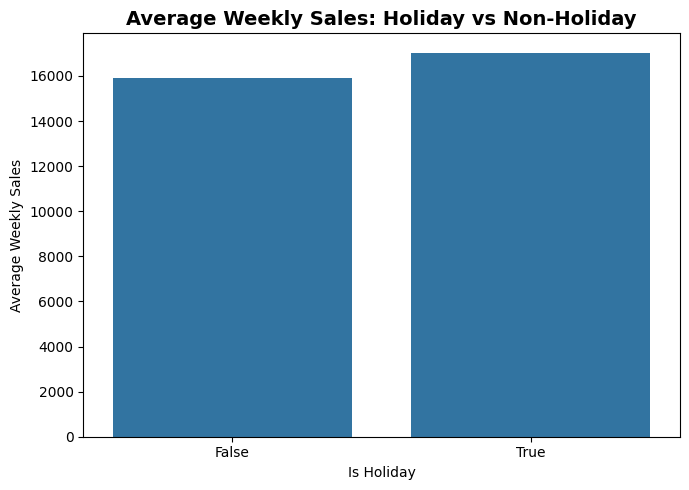

In [19]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=sales_by_holiday,
    x="is_holiday",
    y="avg_weekly_sales"
)

plt.title("Average Weekly Sales: Holiday vs Non-Holiday", fontsize=14, fontweight="bold")
plt.xlabel("Is Holiday")
plt.ylabel("Average Weekly Sales")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "holiday_vs_nonholiday_sales.png", dpi=300)
plt.show()

In [20]:
df_clean = df_clean.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

df_clean[["Store", "Dept", "Date", "Weekly_Sales"]].head()

,Store,Dept,Date,Weekly_Sales
0,1,1,2010-02-05,24924.50
1,1,1,2010-02-12,46039.49
2,1,1,2010-02-19,41595.55
3,1,1,2010-02-26,19403.54
4,1,1,2010-03-05,21827.90


In [21]:
df_clean["sales_lag_1"] = df_clean.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1)
df_clean["sales_lag_2"] = df_clean.groupby(["Store", "Dept"])["Weekly_Sales"].shift(2)
df_clean["sales_lag_4"] = df_clean.groupby(["Store", "Dept"])["Weekly_Sales"].shift(4)

df_clean[[
    "Store", "Dept", "Date", "Weekly_Sales",
    "sales_lag_1", "sales_lag_2", "sales_lag_4"
]].head(10)

,Store,Dept,Date,Weekly_Sales,sales_lag_1,sales_lag_2,sales_lag_4
0,1,1,2010-02-05,24924.50,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,24924.50,NaN,NaN
2,1,1,2010-02-19,41595.55,46039.49,24924.50,NaN
3,1,1,2010-02-26,19403.54,41595.55,46039.49,NaN
4,1,1,2010-03-05,21827.90,19403.54,41595.55,24924.50
5,1,1,2010-03-12,21043.39,21827.90,19403.54,46039.49
6,1,1,2010-03-19,22136.64,21043.39,21827.90,41595.55
7,1,1,2010-03-26,26229.21,22136.64,21043.39,19403.54
8,1,1,2010-04-02,57258.43,26229.21,22136.64,21827.90
9,1,1,2010-04-09,42960.91,57258.43,26229.21,21043.39


In [22]:
df_clean["rolling_mean_4"] = (
    df_clean.groupby(["Store", "Dept"])["Weekly_Sales"]
    .shift(1)
    .rolling(window=4)
    .mean()
)

df_clean["rolling_mean_8"] = (
    df_clean.groupby(["Store", "Dept"])["Weekly_Sales"]
    .shift(1)
    .rolling(window=8)
    .mean()
)

df_clean[[
    "Store", "Dept", "Date", "Weekly_Sales",
    "rolling_mean_4", "rolling_mean_8"
]].head(12)

,Store,Dept,Date,Weekly_Sales,rolling_mean_4,rolling_mean_8
0,1,1,2010-02-05,24924.50,NaN,NaN
1,1,1,2010-02-12,46039.49,NaN,NaN
2,1,1,2010-02-19,41595.55,NaN,NaN
3,1,1,2010-02-26,19403.54,NaN,NaN
4,1,1,2010-03-05,21827.90,32990.7700,NaN
5,1,1,2010-03-12,21043.39,32216.6200,NaN
6,1,1,2010-03-19,22136.64,25967.5950,NaN
7,1,1,2010-03-26,26229.21,21102.8675,NaN
8,1,1,2010-04-02,57258.43,22809.2850,27900.02750
9,1,1,2010-04-09,42960.91,31666.9175,31941.76875


In [23]:
model_df = df_clean.dropna(subset=[
    "sales_lag_1",
    "sales_lag_2",
    "sales_lag_4",
    "rolling_mean_4",
    "rolling_mean_8"
]).copy()

print("Original shape:", df_clean.shape)
print("Model dataset shape:", model_df.shape)

Original shape: (421570, 26)
Model dataset shape: (395604, 26)


In [24]:
features = [
    "Store",
    "Dept",
    "IsHoliday",
    "Temperature",
    "Fuel_Price",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
    "CPI",
    "Unemployment",
    "Type",
    "Size",
    "year",
    "month",
    "week",
    "quarter",
    "sales_lag_1",
    "sales_lag_2",
    "sales_lag_4",
    "rolling_mean_4",
    "rolling_mean_8"
]

target = "Weekly_Sales"

X = model_df[features]
y = model_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (395604, 23)
y shape: (395604,)


In [25]:
split_date = "2012-06-01"

train_df = model_df[model_df["Date"] < split_date]
test_df = model_df[model_df["Date"] >= split_date]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Train period:", train_df["Date"].min(), "to", train_df["Date"].max())
print("Test period:", test_df["Date"].min(), "to", test_df["Date"].max())
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Train period: 2010-04-02 00:00:00 to 2012-05-25 00:00:00
Test period: 2012-06-01 00:00:00 to 2012-10-26 00:00:00
X_train: (330618, 23)
X_test: (64986, 23)


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

numeric_features = [
    "Store",
    "Dept",
    "Temperature",
    "Fuel_Price",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
    "CPI",
    "Unemployment",
    "Size",
    "year",
    "month",
    "week",
    "quarter",
    "sales_lag_1",
    "sales_lag_2",
    "sales_lag_4",
    "rolling_mean_4",
    "rolling_mean_8"
]

categorical_features = [
    "IsHoliday",
    "Type"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [27]:
def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Avoid division by zero for MAPE
    non_zero = y_true != 0
    mape = np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100

    return mae, rmse, mape, r2

In [31]:
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=30,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=50,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

model_results = []
trained_models = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae, rmse, mape, r2 = evaluate_forecast(y_test.values, y_pred)
    
    model_results.append({
        "model": model_name,
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "r2_score": r2
    })
    
    trained_models[model_name] = pipeline

model_comparison = pd.DataFrame(model_results).sort_values("rmse")

model_comparison

Training Linear Regression...
Training Random Forest...
Training Gradient Boosting...


,model,mae,rmse,mape,r2_score
1,Random Forest,1419.561983,3040.969345,1662.533000,0.980953
0,Linear Regression,1711.832752,3312.073169,5577.455627,0.977406
2,Gradient Boosting,2054.753616,3592.623074,12665.731462,0.973416


In [32]:
best_model_name = model_comparison.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

Best model: Random Forest


In [33]:
y_pred_best = best_model.predict(X_test)

forecast_result = test_df[[
    "Store",
    "Dept",
    "Date",
    "Weekly_Sales"
]].copy()

forecast_result["predicted_sales"] = y_pred_best
forecast_result["prediction_error"] = forecast_result["Weekly_Sales"] - forecast_result["predicted_sales"]
forecast_result["absolute_error"] = np.abs(forecast_result["prediction_error"])

forecast_result.head()

,Store,Dept,Date,Weekly_Sales,predicted_sales,prediction_error,absolute_error
121,1,1,2012-06-01,16065.49,17902.267568,-1836.777568,1836.777568
122,1,1,2012-06-08,17666.00,16854.924780,811.075220,811.075220
123,1,1,2012-06-15,17558.82,17698.109544,-139.289544,139.289544
124,1,1,2012-06-22,16633.41,17698.109544,-1064.699544,1064.699544
125,1,1,2012-06-29,15722.82,17049.996813,-1327.176813,1327.176813


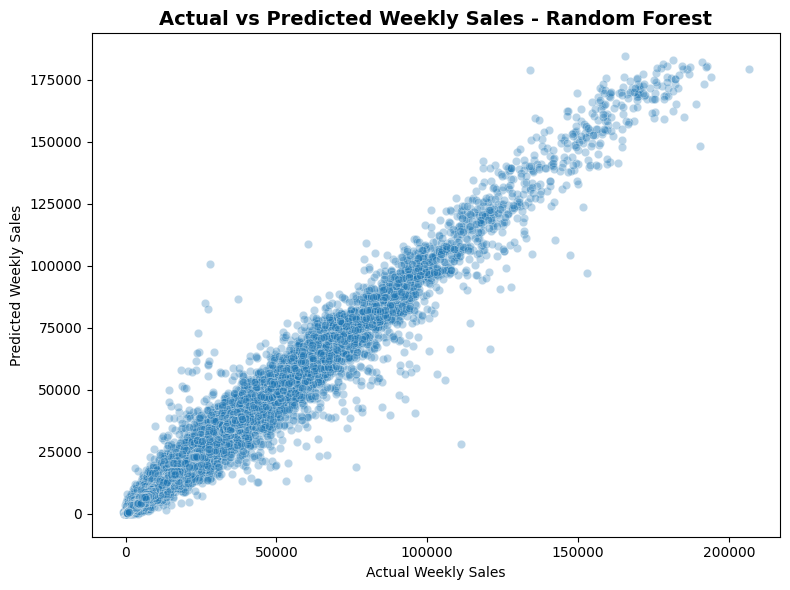

In [34]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=forecast_result["Weekly_Sales"],
    y=forecast_result["predicted_sales"],
    alpha=0.3
)

plt.title(f"Actual vs Predicted Weekly Sales - {best_model_name}", fontsize=14, fontweight="bold")
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "actual_vs_predicted_sales.png", dpi=300)
plt.show()

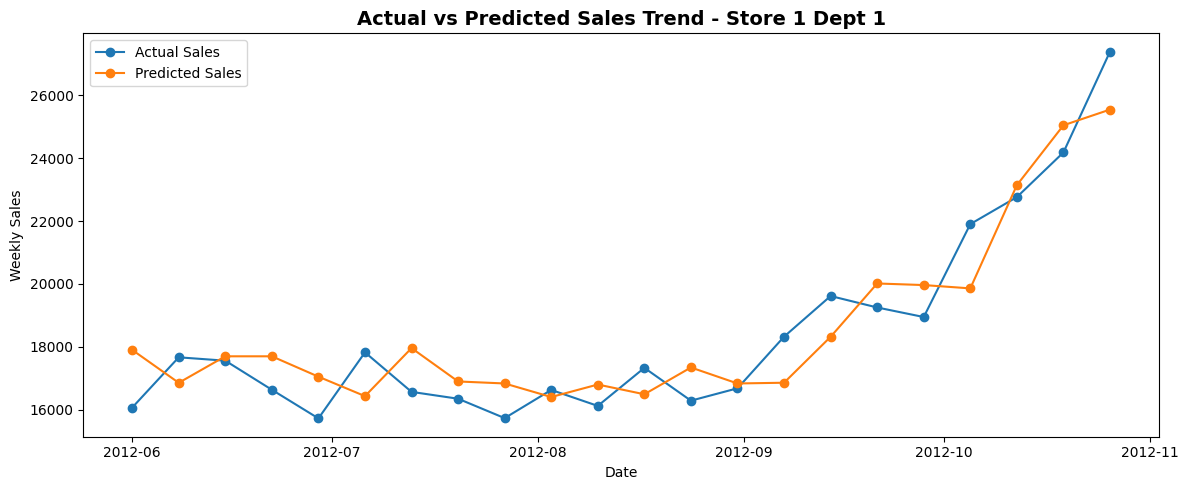

In [35]:
sample_forecast = forecast_result[
    (forecast_result["Store"] == 1) &
    (forecast_result["Dept"] == 1)
].copy()

plt.figure(figsize=(12, 5))

plt.plot(
    sample_forecast["Date"],
    sample_forecast["Weekly_Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    sample_forecast["Date"],
    sample_forecast["predicted_sales"],
    marker="o",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales Trend - Store 1 Dept 1", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()

plt.savefig(VISUAL_PATH + "forecast_trend_store1_dept1.png", dpi=300)
plt.show()

In [36]:
forecast_error_summary = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error",
        "Root Mean Squared Error",
        "R2 Score",
        "Best Model"
    ],
    "Value": [
        model_comparison.iloc[0]["mae"],
        model_comparison.iloc[0]["rmse"],
        model_comparison.iloc[0]["r2_score"],
        best_model_name
    ]
})

forecast_error_summary

,Metric,Value
0,Mean Absolute Error,1419.561983
1,Root Mean Squared Error,3040.969345
2,R2 Score,0.980953
3,Best Model,Random Forest


In [37]:
forecast_by_store = forecast_result.groupby("Store", as_index=False).agg({
    "Weekly_Sales": "sum",
    "predicted_sales": "sum",
    "absolute_error": "mean"
})

forecast_by_store = forecast_by_store.rename(columns={
    "Weekly_Sales": "actual_total_sales",
    "predicted_sales": "predicted_total_sales",
    "absolute_error": "avg_absolute_error"
})

forecast_by_store["sales_gap"] = (
    forecast_by_store["actual_total_sales"] -
    forecast_by_store["predicted_total_sales"]
)

forecast_by_store = forecast_by_store.sort_values(
    by="avg_absolute_error",
    ascending=False
)

forecast_by_store.head(10)

,Store,actual_total_sales,predicted_total_sales,avg_absolute_error,sales_gap
13,14,37116269.71,3.786228e+07,2605.386427,-746007.910442
19,20,45988694.58,4.608130e+07,2435.960458,-92606.753619
26,27,38002367.14,3.833708e+07,2206.238515,-334707.955938
22,23,31791296.76,3.206316e+07,2181.710725,-271865.960672
27,28,27332400.94,2.744116e+07,2178.863597,-108759.521505
3,4,47370986.89,4.755156e+07,2054.432092,-180576.156757
12,13,45017592.40,4.515755e+07,2050.135214,-139954.451299
9,10,38871644.97,3.914729e+07,1975.879544,-275647.169910
1,2,41536882.28,4.176717e+07,1930.408338,-230289.377690
18,19,30736613.55,3.104781e+07,1910.802323,-311192.337739


In [38]:
forecast_by_dept = forecast_result.groupby("Dept", as_index=False).agg({
    "Weekly_Sales": "sum",
    "predicted_sales": "sum",
    "absolute_error": "mean"
})

forecast_by_dept = forecast_by_dept.rename(columns={
    "Weekly_Sales": "actual_total_sales",
    "predicted_sales": "predicted_total_sales",
    "absolute_error": "avg_absolute_error"
})

forecast_by_dept["sales_gap"] = (
    forecast_by_dept["actual_total_sales"] -
    forecast_by_dept["predicted_total_sales"]
)

forecast_by_dept = forecast_by_dept.sort_values(
    by="avg_absolute_error",
    ascending=False
)

forecast_by_dept.head(10)

,Dept,actual_total_sales,predicted_total_sales,avg_absolute_error,sales_gap
36,38,59169893.53,5.964488e+07,5418.333969,-4.749881e+05
59,72,39260487.53,3.880359e+07,4584.283745,4.568958e+05
72,92,77140148.65,7.671634e+07,4546.374497,4.238108e+05
2,3,15417358.16,1.478446e+07,4459.810320,6.328935e+05
75,95,72660033.99,7.338685e+07,3982.849916,-7.268147e+05
56,65,1060368.56,1.072110e+06,3369.044704,-1.174117e+04
10,11,15239720.64,1.516867e+07,3330.061957,7.104746e+04
8,9,23369918.17,2.381536e+07,3151.321988,-4.454465e+05
14,16,15129429.95,1.696563e+07,2977.098615,-1.836201e+06
6,7,20773364.16,2.104086e+07,2692.249235,-2.674973e+05


In [39]:
# Save best model
joblib.dump(best_model, MODEL_PATH + "retail_sales_forecasting_model.pkl")

# Save processed datasets
df_clean.to_csv(PROCESSED_PATH + "walmart_sales_cleaned.csv", index=False)
model_df.to_csv(PROCESSED_PATH + "walmart_sales_model_data.csv", index=False)

kpi_summary.to_csv(PROCESSED_PATH + "kpi_summary.csv", index=False)
monthly_sales.to_csv(PROCESSED_PATH + "monthly_sales.csv", index=False)
sales_by_store.to_csv(PROCESSED_PATH + "sales_by_store.csv", index=False)
sales_by_dept.to_csv(PROCESSED_PATH + "sales_by_department.csv", index=False)
sales_by_holiday.to_csv(PROCESSED_PATH + "sales_by_holiday.csv", index=False)
sales_by_store_type.to_csv(PROCESSED_PATH + "sales_by_store_type.csv", index=False)

model_comparison.to_csv(PROCESSED_PATH + "model_comparison.csv", index=False)
forecast_result.to_csv(PROCESSED_PATH + "forecast_result.csv", index=False)
forecast_error_summary.to_csv(PROCESSED_PATH + "forecast_error_summary.csv", index=False)
forecast_by_store.to_csv(PROCESSED_PATH + "forecast_by_store.csv", index=False)
forecast_by_dept.to_csv(PROCESSED_PATH + "forecast_by_department.csv", index=False)

print("All files saved successfully!")
print("Best model:", best_model_name)
print("Model saved to:", MODEL_PATH + "retail_sales_forecasting_model.pkl")
print("Cleaned data shape:", df_clean.shape)
print("Model data shape:", model_df.shape)
print("Forecast result shape:", forecast_result.shape)

All files saved successfully!
Best model: Random Forest
Model saved to: ../model/retail_sales_forecasting_model.pkl
Cleaned data shape: (421570, 26)
Model data shape: (395604, 26)
Forecast result shape: (64986, 7)
